In [5]:
import numpy as np
import h5py as h5
from matplotlib import pyplot as plt
from IPython.display import Image
import tensorflow as tf
from omnifold import DataLoader, MultiFold, MLP, SetStyle, HistRoutine

Horovod not found, will continue with single only GPUs.


In [6]:
def detector(x,std = 0.5):
    """ Create a fake detector response that smears the inputs given a gaussian distribution with mean 0 and std"""
    return x + np.random.normal(size=x.shape)*std

In [7]:
nevts = 1_000_000 #Number of training events we are going to use
ndim = 4 #Number of features we are going to create

In [8]:
gen_data = np.random.normal(size=(nevts,ndim),loc=ndim*[0.0],scale=ndim*[1.0])
reco_data = detector(gen_data)
gen_mc = np.random.normal(size=(nevts,ndim),loc=ndim*[1.0],scale=ndim*[1.0])
reco_mc = detector(gen_mc)

data = DataLoader(reco = reco_data,normalize=True)
mc = DataLoader(reco = reco_mc,gen = gen_mc,normalize=True)

INFO: Creating weights ...
INFO: Creating pass reco flag ...
INFO: Normalizing sum of weights to 1000000 ...
INFO: Creating weights ...
INFO: Creating pass reco flag ...
INFO: Creating pass gen flag ...
INFO: Normalizing sum of weights to 1000000 ...


In [9]:
print(gen_data)

[[ 2.08278393 -0.10696656 -1.10102439  1.98615778]
 [-1.33626101 -0.8139002   0.02343173 -1.11575334]
 [-0.09797684 -2.08269231  0.5584583   0.11562162]
 ...
 [-0.75731807  1.02619347  0.19899491 -0.57043296]
 [ 2.12588229  0.0297953   0.30207551  0.8406535 ]
 [-0.64354345 -0.41722984  0.03429542 -1.27930636]]


(<Figure size 900x900 with 2 Axes>,
 <Axes: ylabel='Normalized number of events'>)

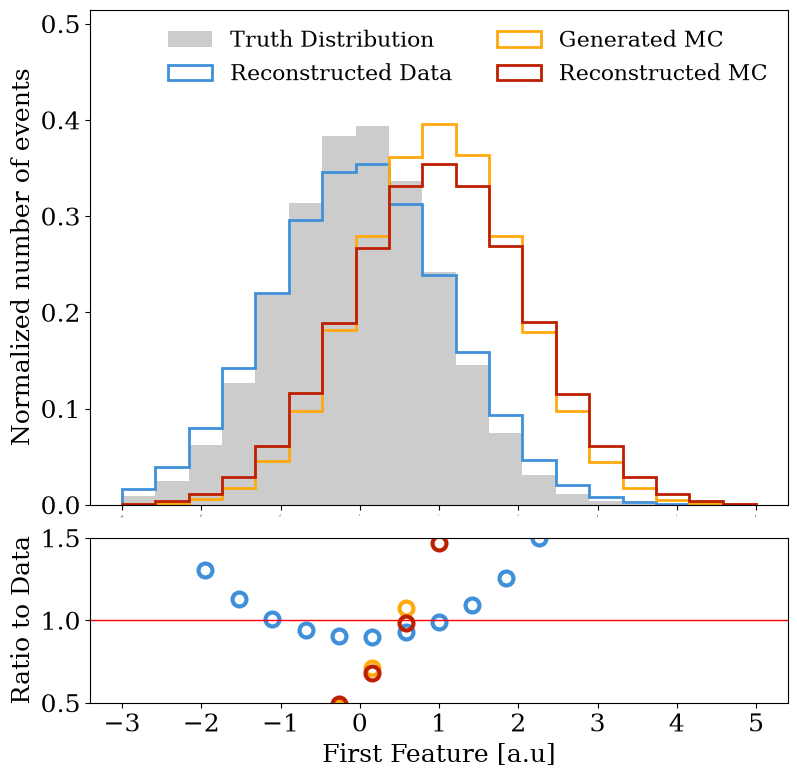

In [5]:
SetStyle()
data_dict = {
    'Truth Distribution': gen_data[:,0],
    'Reconstructed Data': reco_data[:,0],
    'Generated MC': gen_mc[:,0],
    'Reconstructed MC': reco_mc[:,0],
}
HistRoutine(data_dict,'First Feature [a.u]', reference_name = 'Truth Distribution',plot_ratio=True, binning = np.linspace(-3,5,20),)

In [6]:
model1 = MLP(ndim)
model2 = MLP(ndim)

In [7]:
omnifold = MultiFold(
    "Gaussian_test",
    model1,
    model2,
    data,
    mc,
    batch_size = 512,
    niter = 5,  #Number of Iterations                                                                                                                                                                                                  
    epochs=100,     
    weights_folder = 'weights',
    verbose = True,
    lr = 5e-5,
)

3906 training steps at reco and 3906 steps at gen


In [8]:
omnifold.Unfold()

ITERATION: 1
RUNNING STEP 1
Creating cached data from step 1
################################################################################
Train events used: 1999872, Test events used: 399974
################################################################################
Epoch 1/100
3124/3124 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.4245 - val_loss: 0.4052 - learning_rate: 5.0000e-05
Epoch 2/100
3124/3124 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4038 - val_loss: 0.4051 - learning_rate: 5.0000e-05
Epoch 3/100
3124/3124 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4037 - val_loss: 0.4051 - learning_rate: 5.0000e-05
Epoch 4/100
3124/3124 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4037 - val_loss: 0.4051 - learning_rate: 5.0000e-05
Epoch 5/100
3124/3124 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4038 - val_loss: 0.4053 - learning_rate: 5.0000e-05
Epoch 6/100
3124/3124 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4037 - val_loss: 0.4051 - learning_rate: 5.0000e-05
Epoch 7/100
3124/3124 

In [9]:
validation_data = np.random.normal(size=(5*nevts,ndim),loc=ndim*[1.0],scale=ndim*[1.0])
unfolded_weights  = omnifold.reweight(validation_data,omnifold.model2,batch_size=1000)

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 4s 723us/step


In [10]:
print(unfolded_weights)

[0.05639159 2.03688002 0.0893845  ... 0.11074446 0.68316096 0.6927008 ]


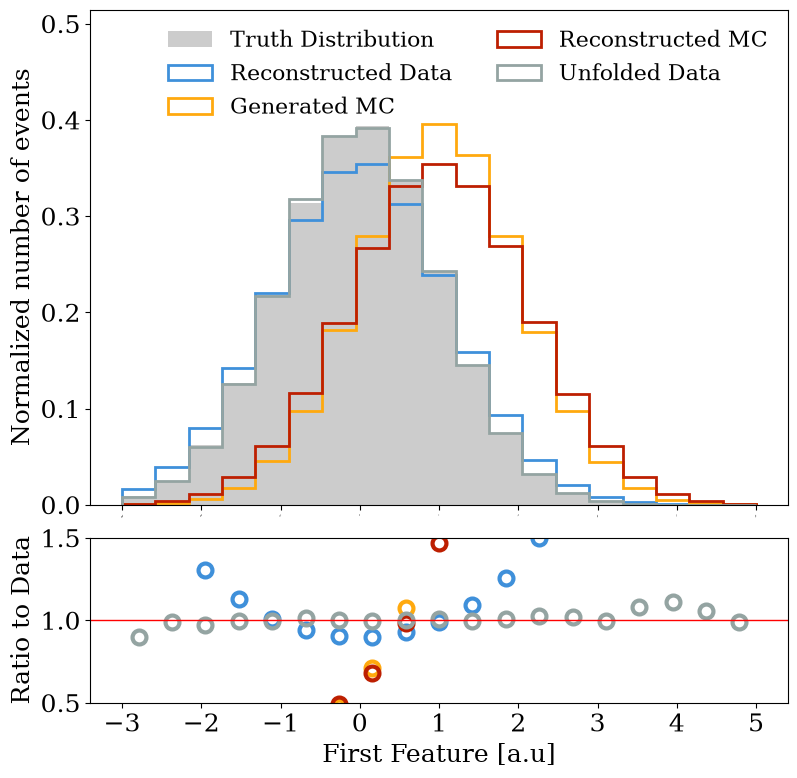

In [11]:
data_dict = {
    'Truth Distribution': gen_data[:,0],
    'Reconstructed Data': reco_data[:,0],
    'Generated MC': gen_mc[:,0],
    'Reconstructed MC': reco_mc[:,0],
    'Unfolded Data': validation_data[:,0],
}

weight_dict = {
    'Truth Distribution': data.weight,
    'Reconstructed Data': data.weight,
    'Generated MC': mc.weight,
    'Reconstructed MC': mc.weight,
    'Unfolded Data': unfolded_weights,
    }

fig,_ = HistRoutine(data_dict,'First Feature [a.u]',
                    reference_name = 'Truth Distribution',
                    weights = weight_dict,
                    plot_ratio = True,
                    binning = np.linspace(-3,5,20)
                    )